Current directory: ['.config', '__MACOSX', 'UCI_HAR_Dataset', 'UCI HAR Dataset.zip', 'sample_data']
UCI_HAR_Dataset contents: ['.DS_Store', 'activity_labels.txt', 'train', 'features.txt', 'test', 'features_info.txt', 'README.txt']


/tmp/ipython-input-905952231.py:38: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  X_train['time'] = pd.date_range(start='2025-12-02 00:00:00', periods=len(X_train), freq='0.01S')



First 5 rows of data:
1  tBodyAcc_X  tBodyAcc_Y  tBodyAcc_Z  tBodyAcc-std()-X  tBodyAcc-std()-Y  \
0    0.288585   -0.020294   -0.132905         -0.995279         -0.983111   
1    0.278419   -0.016411   -0.123520         -0.998245         -0.975300   
2    0.279653   -0.019467   -0.113462         -0.995380         -0.967187   
3    0.279174   -0.026201   -0.123283         -0.996091         -0.983403   
4    0.276629   -0.016570   -0.115362         -0.998139         -0.980817   

1  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  tBodyAcc-mad()-Z  \
0         -0.913526         -0.995112         -0.983185         -0.923527   
1         -0.960322         -0.998807         -0.974914         -0.957686   
2         -0.978944         -0.996520         -0.963668         -0.977469   
3         -0.990675         -0.997099         -0.982750         -0.989302   
4         -0.990482         -0.998321         -0.979672         -0.990441   

1  tBodyAcc-max()-X  ...  fBodyBodyGyroJerkMag-skew

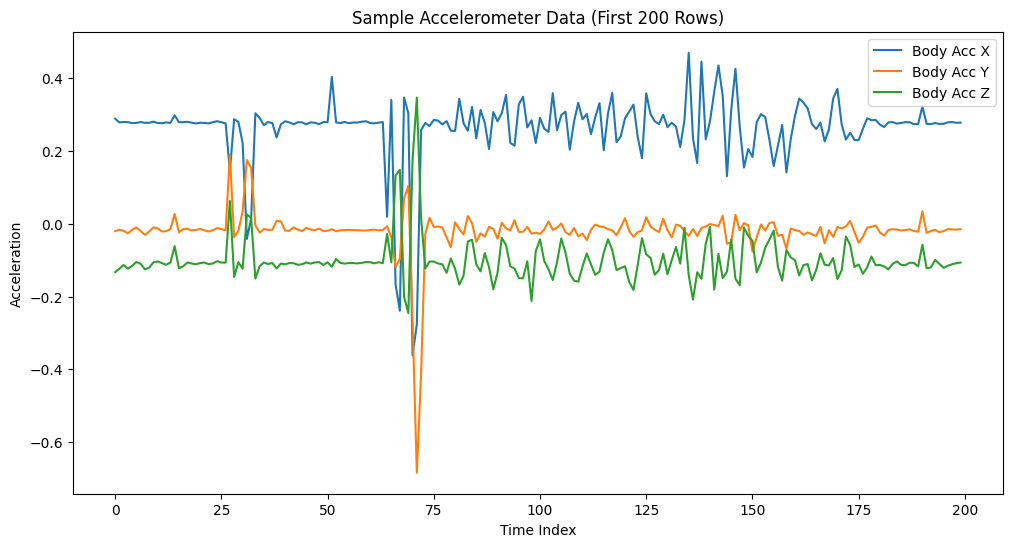

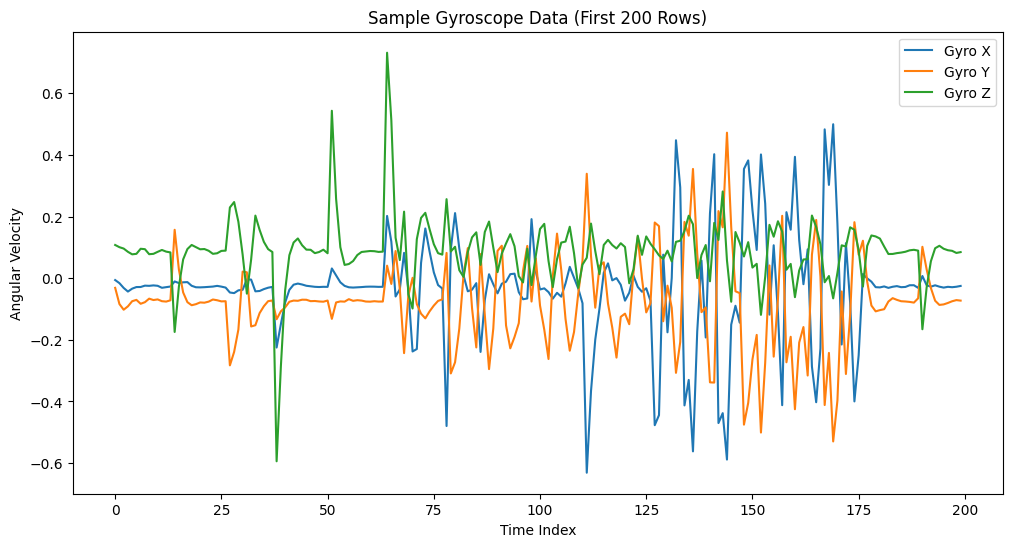

In [13]:

# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import os

# 2. Verify directory structure
print("Current directory:", os.listdir())
print("UCI_HAR_Dataset contents:", os.listdir("UCI_HAR_Dataset"))

# 3. Load Dataset
X_train = pd.read_csv('UCI_HAR_Dataset/train/X_train.txt', sep=r'\s+', header=None)
y_train = pd.read_csv('UCI_HAR_Dataset/train/y_train.txt', sep=r'\s+', header=None)
features = pd.read_csv('UCI_HAR_Dataset/features.txt', sep=r'\s+', header=None)
activity_labels = pd.read_csv('UCI_HAR_Dataset/activity_labels.txt', sep=r'\s+', header=None, index_col=0)

# Set column names
X_train.columns = features[1]
# Map activity labels
y_train[0] = y_train[0].map(activity_labels[1])

# Rename accelerometer and gyroscope columns for plotting
rename_dict = {
    'tBodyAcc-mean()-X': 'tBodyAcc_X',
    'tBodyAcc-mean()-Y': 'tBodyAcc_Y',
    'tBodyAcc-mean()-Z': 'tBodyAcc_Z',
    'tBodyGyro-mean()-X': 'tBodyGyro_X',
    'tBodyGyro-mean()-Y': 'tBodyGyro_Y',
    'tBodyGyro-mean()-Z': 'tBodyGyro_Z'
}

X_train.rename(columns=rename_dict, inplace=True)


# 5. Add time column (optional)
X_train['time'] = pd.date_range(start='2025-12-02 00:00:00', periods=len(X_train), freq='0.01S')

# 6. Handle missing values
X_train.ffill(inplace=True)

# 7. Remove duplicates
X_train.drop_duplicates(inplace=True)

# 8. Explore Data
print("\nFirst 5 rows of data:")
print(X_train.head())

print("\nActivity counts:")
print(y_train[0].value_counts())

# 9. Plot sample accelerometer data
plt.figure(figsize=(12,6))
plt.plot(X_train['tBodyAcc_X'][:200], label='Body Acc X')
plt.plot(X_train['tBodyAcc_Y'][:200], label='Body Acc Y')
plt.plot(X_train['tBodyAcc_Z'][:200], label='Body Acc Z')
plt.legend()
plt.title('Sample Accelerometer Data (First 200 Rows)')
plt.xlabel('Time Index')
plt.ylabel('Acceleration')
plt.show()

# 10. Plot sample gyroscope data
plt.figure(figsize=(12,6))
plt.plot(X_train['tBodyGyro_X'][:200], label='Gyro X')
plt.plot(X_train['tBodyGyro_Y'][:200], label='Gyro Y')
plt.plot(X_train['tBodyGyro_Z'][:200], label='Gyro Z')
plt.legend()
plt.title('Sample Gyroscope Data (First 200 Rows)')
plt.xlabel('Time Index')
plt.ylabel('Angular Velocity')
plt.show()